# Gradient Descent for Logistic Regression

# Goals

In this lab, we will:

- Explore the sigmoid (logistic) function

- Understand logistic regression

- Examine the cost function for logistic regression

- Update gradient descent for logistic regression

- Apply gradient descent to a dataset

In [1]:
# First, install the required package
#!pip install ipympl
import copy, math
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from lab_utils_common import dlc, plot_data, plt_tumor_data, sigmoid, compute_cost_logistic
from plt_quad_logistic import plt_quad_logistic, plt_prob
plt.style.use('./deeplearning.mplstyle')

## Dataset

In [2]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])                                           #(m,)

## Logistic Regression
A logistic regression model applies the sigmoid to the familiar linear regression model as shown below:

$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b ) \tag{2} $$ 

  where

  $g(z) = \frac{1}{1+e^{-z}}\tag{3}$

In [3]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z
         
    """
    g = 1/(1+np.exp(-z))

    return g

## Loss Function

In logistic regression, the loss function is specifically designed for binary classification tasks, where the target variable y is either 0 or 1. This loss function effectively captures the difference between the model's prediction and the actual target for a single training example.

The loss for one data point is defined as:

\begin{equation}
  loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = \begin{cases}
    - \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=1$}\\
    - \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=0$}
  \end{cases}
\end{equation}

This can be written more compactly using a single expression:

 $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$

where m is the number of training examples in the data set and:
$$
\begin{align}
  f_{\mathbf{w},b}(\mathbf{x^{(i)}}) &= g(z^{(i)})\tag{3} \\
  z^{(i)} &= \mathbf{w} \cdot \mathbf{x}^{(i)}+ b\tag{4} \\
  g(z^{(i)}) &= \frac{1}{1+e^{-z^{(i)}}}\tag{5} 
\end{align}
$$

This formulation ensures that the loss is small when the prediction is close to the true label and increases rapidly as the prediction diverges from the actual target. The loss function therefore penalizes incorrect predictions more heavily, promoting learning that improves classification accuracy.

## Cost Function

While the loss measures the error on a single example, the cost function aggregates this loss over the entire training dataset. The cost function for logistic regression is defined as:

$$ J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

where
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point.

This average cost across all training examples serves as the objective to be minimized during training, guiding the optimization process in adjusting the parameters w and b to improve model performance.

In [4]:
def compute_cost_logistic(X, y, w, b):
    """
    Computes cost

    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
    """
    
    m = X.shape[0]
    loss = 0.0
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb = sigmoid(z_i)
        loss += - y[i]* np.log(f_wb) - (1 - y[i]) * np.log(f_wb)

    cost = loss/m
    return cost 

## Logistic Gradient Descent

the gradient descent algorithm utilizes the gradient calculation:
$$\begin{align*}
&\text{repeat until convergence:} \; \lbrace \\
&  \; \; \;w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1} \\ 
&  \; \; \;  \; \;b = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \\
&\rbrace
\end{align*}$$

Where each iteration performs simultaneous updates on $w_j$ for all $j$, where
$$\begin{align*}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{2} \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{3} 
\end{align*}$$

* m is the number of training examples in the data set      
* $f_{\mathbf{w},b}(x^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target
* For a logistic regression model  
    $z = \mathbf{w} \cdot \mathbf{x} + b$  
    $f_{\mathbf{w},b}(x) = g(z)$  
    where $g(z)$ is the sigmoid function:  
    $g(z) = \frac{1}{1+e^{-z}}$   
    


In [5]:
def compute_gradient_logistic(X, y, w, b): 
    """
    Computes the gradient for logistic regression 
 
    Args:
      X (ndarray (m,n): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar)      : model parameter
    Returns
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar)      : The gradient of the cost w.r.t. the parameter b. 
    """

    m,n = X.shape
    dj_dw = np.zeros((n,))                          
    dj_db = 0
    
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb = sigmoid(z_i)
        err = f_wb - y[i]
        for j in range(n):
            dj_dw[j]  += err * X[i,j]
        dj_db += err
        
    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_db, dj_dw     

#### Gradient Descent Code 
The code implementing equation (1) above is implemented below.

In [6]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    """
    Performs batch gradient descent
    
    Args:
      X (ndarray (m,n)   : Data, m examples with n features
      y (ndarray (m,))   : target values
      w_in (ndarray (n,)): Initial values of model parameters  
      b_in (scalar)      : Initial values of model parameter
      alpha (float)      : Learning rate
      num_iters (scalar) : number of iterations to run gradient descent
      
    Returns:
      w (ndarray (n,))   : Updated values of parameters
      b (scalar)         : Updated value of parameter 
    """

    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in

    for i in range(num_iters):
        # Calculate the gradient and update the parameters
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( compute_cost_logistic(X, y, w, b) )

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]}   ")
        
    return w, b, J_history 

In [7]:
w_tmp  = np.zeros_like(X_train[0])
b_tmp  = 0.
alph = 0.1
iters = 10000

w_out, b_out, _ = gradient_descent(X_train, y_train, w_tmp, b_tmp, alph, iters) 
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.6637771352272405   
Iteration 1000: Cost 0.923029532359377   
Iteration 2000: Cost 1.1926866794865707   
Iteration 3000: Cost 1.3722581039311132   
Iteration 4000: Cost 1.505711006956071   
Iteration 5000: Cost 1.6116169881474842   
Iteration 6000: Cost 1.699300964397468   
Iteration 7000: Cost 1.774066660906983   
Iteration 8000: Cost 1.8392076785357154   
Iteration 9000: Cost 1.896905685253351   

updated parameters: w:[5.28 5.08], b:-14.222409982019837


#### Let's plot the results of gradient descent:

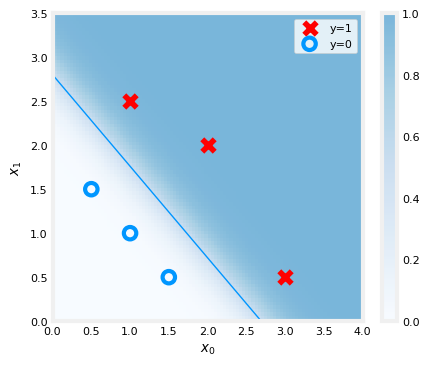

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# Plot the model's predicted probabilities
plt_prob(ax, w_out, b_out)

# Plot the training data
plot_data(X_train, y_train, ax)

# Axis labels and limits
ax.set_xlabel(r'$x_0$')
ax.set_ylabel(r'$x_1$')
ax.axis([0, 4, 0, 3.5])

# Plot the decision boundary
x0 = -b_out / w_out[0]
x1 = -b_out / w_out[1]
ax.plot([0, x0], [x1, 0], c=dlc["dlblue"], lw=1)

# Show the plot
plt.show()


In the plot above:
 - the shading reflects the probability y=1 (result prior to decision boundary)
 - the decision boundary is the line at which the probability = 0.5
 

In [11]:
print(f"b, w found by gradient descent: {b_out:.2f}, {w_out}\n")

m, _ = X_train.shape
for i in range(m):
    x0, x1 = X_train[i]
    w0, w1 = w_out
    z = w0 * x0 + w1 * x1 + b_out
    print(f"z = {z:.2f} | target: {y_train[i]}")


b, w found by gradient descent: -14.22, [5.28 5.08]

z = -3.96 | target: 0
z = -3.86 | target: 0
z = -3.76 | target: 0
z = 4.16 | target: 1
z = 6.50 | target: 1
z = 3.75 | target: 1
